# Partition

In [ ]:
#| hide
from programming_first_principles.core import prepare_notebook
from programming_first_principles.helpers.predicates import above_35, below_5000
from programming_first_principles.helpers.cost import Cost
from programming_first_principles.helpers.variables import scores_out_of_100, scores

import inspect
from collections import namedtuple


<function generate_scores>


In [ ]:
#| hide
prepare_notebook()

In [ ]:
#| hide
#| default_exp algorithms.partition

In [ ]:
print(inspect.getsource(above_35))

def above_35(score):
    """Return whether score is 35 or higher."""
    return score >= 35



#### Single Pass
* Lomuto

In [ ]:
#| exports
from programming_first_principles.algorithms.rearrange import swap

def partition_single_pass(a, first, last, pred):
    n = first
    for i in range(first, last):
        if pred(a[i]):
            if n != i:
                swap(a, n, i)
            n += 1
    return n

In [ ]:
scores_sp = list(scores_out_of_100)
pp1 = partition_single_pass(scores_sp,0,len(scores_sp), above_35)
f'Good: {scores_sp[:pp1] = }'
f'Bad: {scores_sp[pp1:] = }'

'Good: scores_sp[:pp1] = [40, 35, 80, 75, 80]'

'Bad: scores_sp[pp1:] = [5, 5, 10]'

In [ ]:
scores_pp2 = list(scores)
pp2 = partition_single_pass(scores_pp2,0,len(scores_pp2), above_35)
f'{pp2 = }'
f'Good: {scores_pp2[:pp2] = }'
f'Bad: {scores_pp2[pp2:] = }'

'pp2 = 63'

'Good: scores_pp2[:pp2] = [91, 92, 35, 35, 40, 80, 95, 39, 50, 63, 92, 44, 43, 100, 63, 42, 88, 67, 92, 96, 85, 86, 80, 58, 59, 42, 94, 72, 46, 97, 59, 47, 93, 47, 94, 75, 67, 48, 64, 66, 61, 56, 72, 41, 75, 62, 73, 52, 82, 54, 37, 53, 96, 42, 77, 62, 68, 68, 40, 95, 66, 41, 50]'

'Bad: scores_pp2[pp2:] = [4, 8, 1, 30, 9, 34, 16, 2, 28, 32, 10, 30, 14, 14, 15, 23, 7, 14, 6, 16, 14, 26, 12, 13, 3, 13, 6, 19, 10, 32, 29, 18, 22, 1, 25, 28, 32]'

In [ ]:
scores_sp_cost = [40, 10, 35, 5, 80, 75, 5, 80]
predicates = Cost(repeats=1)
_ = predicates.run(partition_single_pass, scores_sp_cost,0,len(scores_sp_cost),above_35, operations=('predicates','swaps','ms'))
predicates.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_single_pass,,8,None,8,4,0.0057


In [ ]:
single_pass = Cost(repeats=5, seed=0)
_ = single_pass.scale([partition_single_pass], args=lambda data: (0, len(data), below_5000), operations=('predicates','swaps','ms'))

single_pass.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_single_pass,random,500,None,500,258,0.0854
1,partition_single_pass,sorted,500,None,500,0,0.0265
2,partition_single_pass,reversed,500,None,500,258,0.0419
3,partition_single_pass,random,1000,None,1000,501,0.2281
4,partition_single_pass,sorted,1000,None,1000,0,0.0534
5,partition_single_pass,reversed,1000,None,1000,501,0.0892
6,partition_single_pass,random,2000,None,2000,988,0.2383
7,partition_single_pass,sorted,2000,None,2000,0,0.1106
8,partition_single_pass,reversed,2000,None,2000,991,0.1631


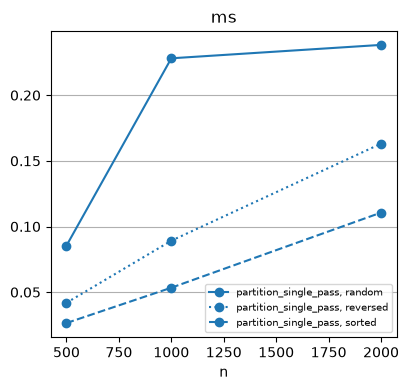

In [ ]:
single_pass.plot('ms')

#### Two Pointer
* Hoare

In [ ]:
#| exports
from programming_first_principles.algorithms.rearrange import swap
def partition_two_pointer(a,first,last, pred):
    lo, hi = first, last - 1
    while lo <= hi:
        if pred(a[lo]):
            lo += 1
        else:
            if not pred(a[hi]):
                hi -= 1
            else:
                swap(a, lo, hi)
                lo += 1
                hi -= 1
    return lo

In [ ]:
scores_2p = list(scores_out_of_100)
two_p_pp1 = partition_two_pointer(scores_2p, 0, len(scores_2p), above_35)
f'{two_p_pp1 = }'
f'Passed: {scores_2p[:two_p_pp1] = }'
f'Failed: {scores_2p[two_p_pp1:] = }'

'two_p_pp1 = 5'

'Passed: scores_2p[:two_p_pp1] = [40, 80, 35, 75, 80]'

'Failed: scores_2p[two_p_pp1:] = [5, 5, 10]'

In [ ]:
scores_d = list(scores_out_of_100)
two_p_pp2 = partition_two_pointer(scores_d, 0, len(scores_d), above_35)
f'{two_p_pp2 = }'
f'Passed: {scores_d[:two_p_pp2] = }'
f'Failed: {scores_d[two_p_pp2:] = }'

'two_p_pp2 = 5'

'Passed: scores_d[:two_p_pp2] = [40, 80, 35, 75, 80]'

'Failed: scores_d[two_p_pp2:] = [5, 5, 10]'

In [ ]:
scores_2p_cost = [40, 10, 35, 5, 80, 75, 5, 80]
predicates = Cost(repeats=1)
_ = predicates.run(partition_two_pointer, scores_2p_cost, 0, len(scores_2p_cost), above_35, operations=('predicates','ms','swaps'))
predicates.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_two_pointer,,8,None,9,2,0.0036


In [ ]:
two_pointer = Cost(repeats=1, seed=0, sizes=(2_000, 8_000, 32_000))
_ = two_pointer.scale([partition_two_pointer], 
                        args=lambda data: (0, len(data), below_5000),
                        operations=('predicates','swaps','ms'))
two_pointer.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_two_pointer,random,2000,None,2521,483,0.2245
1,partition_two_pointer,sorted,2000,None,3004,0,0.2055
2,partition_two_pointer,reversed,2000,None,2008,996,0.2067
3,partition_two_pointer,random,8000,None,9990,1994,0.9462
4,partition_two_pointer,sorted,8000,None,11984,0,1.0539
5,partition_two_pointer,reversed,8000,None,8000,3984,0.8470
6,partition_two_pointer,random,32000,None,39983,7971,3.8695
7,partition_two_pointer,sorted,32000,None,47954,0,2.2725
8,partition_two_pointer,reversed,32000,None,32000,15954,2.8319


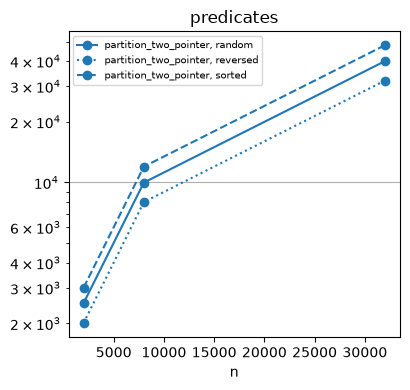

In [ ]:
two_pointer.plot('predicates')

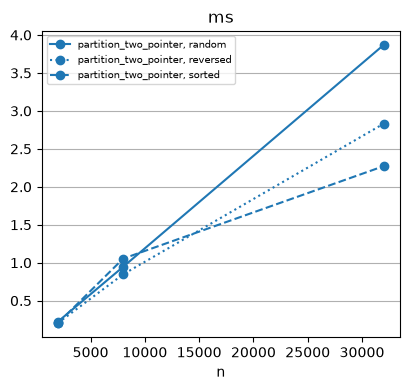

In [ ]:
two_pointer.plot('ms')

#### Custom Data Type

In [ ]:
Student = namedtuple("Student", ["name", "score"])

def student_above_35(s):
    return above_35(s.score)

students = [
    Student("Ana", 22),
    Student("Ben", 41),
    Student("Cai", 35),
    Student("Diya", 90),
    Student("Eli", 18),
    Student("Far", 67),
]

n = partition_two_pointer(students,0, len(students), student_above_35)

f'Passed: {students[:n]}'

"Passed: [Student(name='Far', score=67), Student(name='Ben', score=41), Student(name='Cai', score=35), Student(name='Diya', score=90)]"

#### Is Partitioned

In [ ]:
#| exports
from programming_first_principles.algorithms.find import find_if, find_if_not

def is_partitioned(a, first, last, pred):
    i = find_if_not(a, first, last, pred)
    j = find_if(a, i, last, pred )
    return j == last

In [ ]:
scores_isp = list(scores_out_of_100)

f'{is_partitioned(scores_isp, 0, len(scores_isp), above_35) = }'
partition_point1 = partition_single_pass(scores_isp,0,len(scores_isp), above_35)
f'{scores_isp = }'

f'{is_partitioned(scores_isp, 0, len(scores_isp), above_35) = }'

'is_partitioned(scores_isp, 0, len(scores_isp), above_35) = False'

'scores_isp = [40, 35, 80, 75, 80, 5, 5, 10]'

'is_partitioned(scores_isp, 0, len(scores_isp), above_35) = True'

In [ ]:
good = [40, 60, 75, 80, 20, 5, 3, 10]
raw = [5, 40, 3, 10, 20, 60, 75, 80]

isp = Cost(repeats=1)
_ = isp.run(is_partitioned, good, 0, len(good), above_35,
            shape='partitioned', operations=('predicates', 'ms'))
_ = isp.run(is_partitioned, raw, 0, len(raw), above_35,
            shape='broken', operations=('predicates', 'ms'))
isp.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,is_partitioned,partitioned,8,None,9,None,0.0027
1,is_partitioned,broken,8,None,3,None,0.0027


#### Partition Point

In [ ]:
#| exports
from programming_first_principles.algorithms.find import find_if_not
def partition_point_linear(a, first, last, pred):
    return find_if_not(a, first, last, pred)

In [ ]:
good = [40, 60, 75, 80, 20, 5, 3, 10]
raw = [5, 40, 3, 10, 20, 60, 75, 80]

f'{partition_point_linear(good, 0, len(good), above_35) = }'
f'{partition_point_linear(raw, 0, len(raw), above_35) = }'

'partition_point_linear(good, 0, len(good), above_35) = 4'

'partition_point_linear(raw, 0, len(raw), above_35) = 0'

In [ ]:
front = [5, 3, 10, 20, 8, 1, 2, 4]
mid = [40, 60, 75, 80, 20, 5, 3, 10]
end = [40, 60, 75, 80, 90, 41, 35, 50]

ppl = Cost(repeats=1)
_ = ppl.run(partition_point_linear, front, 0, len(front), above_35,
           shape='point 0', operations=('predicates', 'ms'))
_ = ppl.run(partition_point_linear, mid, 0, len(mid), above_35,
           shape='point 4', operations=('predicates', 'ms'))
_ = ppl.run(partition_point_linear, end, 0, len(end), above_35,
           shape='point 8', operations=('predicates', 'ms'))
ppl.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_point_linear,point 0,8,None,1,None,0.0024
1,partition_point_linear,point 4,8,None,5,None,0.0022
2,partition_point_linear,point 8,8,None,8,None,0.0015


In [ ]:
#| exports  
def partition_point(a, first, last, pred):
    """
    Precondition: is_partitioned(a, first, last, pred).
    Returns the partition point of [first, last).
    """
    while first != last:
        middle = first + (last - first) // 2
        if pred(a[middle]):
            first = middle + 1
        else:
            last = middle
    return first

In [ ]:
good = [40, 60, 75, 80, 20, 5, 3, 10]
raw = [5, 40, 3, 10, 20, 60, 75, 80]
f'{is_partitioned(good, 0, len(good), above_35) = }'
f'{partition_point(good, 0, len(good), above_35) = }'

f'{is_partitioned(raw, 0, len(raw), above_35) = }'
f'{partition_point(raw, 0, len(raw), above_35) = }'

'is_partitioned(good, 0, len(good), above_35) = True'

'partition_point(good, 0, len(good), above_35) = 4'

'is_partitioned(raw, 0, len(raw), above_35) = False'

'partition_point(raw, 0, len(raw), above_35) = 2'

In [ ]:
front = [5, 3, 10, 20, 8, 1, 2, 4]
mid = [40, 60, 75, 80, 20, 5, 3, 10]
end = [40, 60, 75, 80, 90, 41, 35, 50]

pp = Cost(repeats=1)
_ = pp.run(partition_point, front, 0, len(front), above_35,
           shape='point 0', operations=('predicates', 'ms'))
_ = pp.run(partition_point, mid, 0, len(mid), above_35,
           shape='point 4', operations=('predicates', 'ms'))
_ = pp.run(partition_point, end, 0, len(end), above_35,
           shape='point 8', operations=('predicates', 'ms'))
pp.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_point,point 0,8,None,4,None,0.0026
1,partition_point,point 4,8,None,3,None,0.0040
2,partition_point,point 8,8,None,3,None,0.0019


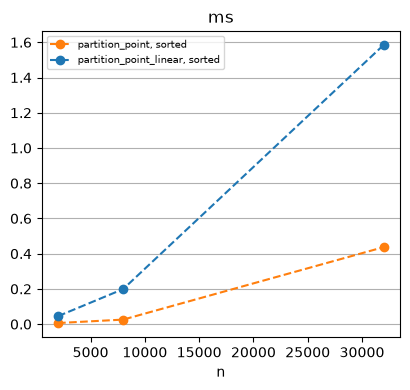

In [ ]:
point = Cost(repeats=5, seed=0, sizes=(2_000, 8_000, 32_000))
_ = point.scale(
    [partition_point_linear, partition_point],
    args=lambda data: (0, len(data), below_5000),
    operations=('ms',),
)
point.plot('ms', frame=point.frame[point.frame['shape'] == 'sorted'])

In [ ]:
from programming_first_principles.algorithms.rearrange import rotate

def partition_stable(a, first, last, pred):
    n = first
    for i in range(first, last):
        if pred(a[i]):
            if n != i:
                rotate(a, n, i, i + 1)
            n += 1
    return n

In [ ]:
scores_stablep = list(scores_out_of_100)
pp_s1 = partition_stable(scores_stablep, 0, len(scores_stablep), above_35)
f'{pp_s1 = }'
f'Good: {scores_stablep[:pp_s1] = }'
f'Bad: {scores_stablep[pp_s1:] = }'

'pp_s1 = 5'

'Good: scores_stablep[:pp_s1] = [40, 35, 80, 75, 80]'

'Bad: scores_stablep[pp_s1:] = [10, 5, 5]'

In [ ]:
scores_sp_cost = list(scores_out_of_100)
stable = Cost(repeats=1)
_ = stable.run(partition_stable, scores_sp_cost, 0, len(scores_sp_cost), above_35, operations=('predicates', 'swaps', 'ms'))
stable.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_stable,,8,None,8,8,0.0054


In [ ]:
stable = Cost(repeats=5, seed=0, sizes=(512, 1024))
_ = stable.scale(
    [partition_stable],
    args=lambda data: (0, len(data), below_5000),
    operations=('predicates', 'swaps', 'ms'),
)
stable.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_stable,random,512,None,512,32233,2.3414
1,partition_stable,sorted,512,None,512,0,0.0279
2,partition_stable,reversed,512,None,512,65500,4.3352
3,partition_stable,random,1024,None,1024,128946,9.0758
4,partition_stable,sorted,1024,None,1024,0,0.0573
5,partition_stable,reversed,1024,None,1024,262095,18.0324


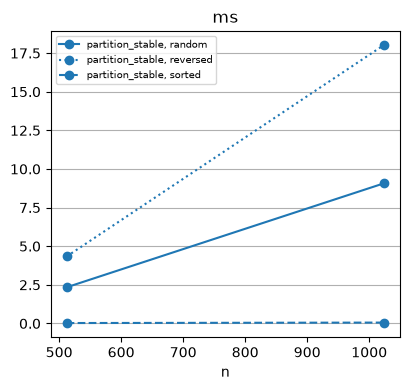

In [ ]:
stable.plot('ms')

In [ ]:
from programming_first_principles.algorithms.rearrange import swap
def v_partition_single_pass(b, pred):
    n = 0
    a = list(b)
    for i in range(len(a)):
        val  = a[i]
        predicate = pred(val)
        if predicate:
            if n != i:
                swap(a, n, i)
            n += 1
        array_state = a[:]
    return n, a
# scores_vsp = [5, 40, 3, 10, 20, 60,75,80]
# LiveEdit.inspect_run(v_partition_single_pass, scores_vsp, above_35)